# Dataset

This model was trained on a custom fruit detection dataset.

Format:
- Images: JPG/PNG
- Labels: YOLO format (class, x_center, y_center, width, height)

Classes:
- apple
- avocado
- banana
- guava
- kiwi
- mango
- orange
- peach
- pineapple

In [ ]:
import torch
import os

im_w, im_h = 640, 640

def yolo_to_frcnn(txt_path, img_w, img_h):
    boxes = []
    labels = []

    with open(txt_path) as f:
        for line in f:
            cls, x_c, y_c, w, h = map(float, line.strip().split())

            x1 = (x_c - w/2) * img_w
            y1 = (y_c - h/2) * img_h
            x2 = (x_c + w/2) * img_w
            y2 = (y_c + h/2) * img_h

            boxes.append([x1, y1, x2, y2])
            labels.append(int(cls) + 1)  # 0 réservé au background

    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)

In [ ]:
import os

def get_label_path(img_name, label_dir):
    base_name = os.path.splitext(img_name)[0]  # supprime l’extension
    return os.path.join(label_dir, base_name + ".txt")

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class FruitDataset(Dataset):
  def __init__(self, img_dir, label_dir, transform = None):
    self.img_dir = img_dir
    self.label_dir = label_dir
    self.imgs = list(sorted(os.listdir(img_dir)))
    self.transform = transform

  def __getitem__(self, idx):
    img_name = self.imgs[idx]

    img_path = os.path.join(self.img_dir, img_name)
    label_path = get_label_path(img_name, self.label_dir)

    # vérifier que les fichiers existent
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Image introuvable: {img_path}")
    if not os.path.exists(label_path):
        raise FileNotFoundError(f"Label introuvable: {label_path}")

    # charger l'image
    img = Image.open(img_path).convert("RGB")

    # convertir annotations
    boxes, labels = yolo_to_frcnn(label_path, img.width, img.height)

    target = {}
    target['boxes'] = boxes
    target['labels'] = labels
    target['image_id'] = torch.tensor([idx])

    if self.transform:
        img = self.transform(img)

    return img, target

  def __len__(self):
    return len(self.imgs)

In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

num_classes = 10

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained = True)
in_features = model.roi_heads.box_predictor.cls_score.in_features

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 188MB/s]


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.ToTensor()

train_dataset = FruitDataset("data/image/train", "data/labels/train", transform=transform)
val_dataset = FruitDataset("data/images/val", "data/labels/val")

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for imgs, targets in train_loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/20, Loss: 0.3402
Epoch 2/20, Loss: 0.2819
Epoch 3/20, Loss: 0.1791
Epoch 4/20, Loss: 0.0859
Epoch 5/20, Loss: 0.4211
Epoch 6/20, Loss: 0.1332
Epoch 7/20, Loss: 0.0472
Epoch 8/20, Loss: 0.2657
Epoch 9/20, Loss: 0.0955
Epoch 10/20, Loss: 0.0975
Epoch 11/20, Loss: 0.0536
Epoch 12/20, Loss: 0.0640
Epoch 13/20, Loss: 0.0620
Epoch 14/20, Loss: 0.0516
Epoch 15/20, Loss: 0.0554
Epoch 16/20, Loss: 0.0273
Epoch 17/20, Loss: 0.0255
Epoch 18/20, Loss: 0.0248
Epoch 19/20, Loss: 0.0906
Epoch 20/20, Loss: 0.1333


## Training Monitoring

Currently tracking training loss.
Future work: add mAP evaluation on validation set.

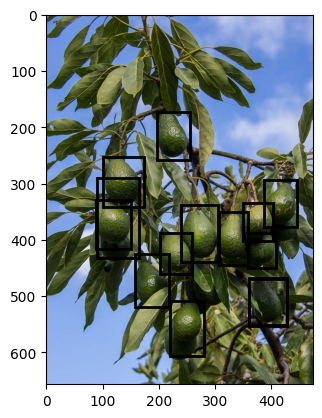

In [ ]:
val_dataset = FruitDataset("data/images/val", "data/labels/val", transform = transform)
import matplotlib.pyplot as plt
import matplotlib.patches as patches

model.eval()

img, _ = val_dataset[5]
img_gpu = img.to(device)

with torch.no_grad():
    prediction = model([img_gpu])

boxes = prediction[0]['boxes'].cpu()
labels = prediction[0]['labels'].cpu()

img_display = img.permute(1, 2, 0).cpu()

plt.imshow(img_display)
ax = plt.gca()

for box in boxes:
    x1, y1, x2, y2 = box
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        fill=False
    )
    ax.add_patch(rect)

plt.show()